# Notebook 02: Multilingual Representation, Sentiment Analysis & Topic Discovery (Stages 3 & 4)

This notebook demonstrates the intermediate NLP and Topic Discovery stages:
- **Stage 3.1**: Contextual Sentence Embeddings using **XLM-RoBERTa** (Attention Mean Pooling, 768 dimensions)
- **Stage 3.2**: Multilingual Sentiment Analysis & Continuous Sentiment Score computation: $S = P(\text{positive}) - P(\text{negative}) \in [-1.0, 1.0]$
- **Stage 3.3**: Exploratory Sentiment Distribution across social platforms and categories
- **Stage 4.1**: Latent Topic Modeling using **BERTopic** (UMAP 5D + HDBSCAN density clustering)
- **Stage 4.2**: Topic Representation via Class-based TF-IDF (**c-TF-IDF**) keyword extraction
- **Stage 4.3**: Topic Inspection, Keyword Ranking, and Interactive Topic Visualization

### 1. Environment Setup & Configuration

In [1]:
import os
import sys

# Ensure current working directory is project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if "." not in sys.path:
    sys.path.append(".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

from src.utils.file_io import load_yaml, load_dataframe, save_dataframe
from src.stage_03_multilingual_sentiment import MultilingualSentimentPipeline
from src.stage_04_topic_detection import TopicDetector

# Set visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

config = load_yaml("configs/config.yaml")
print("Environment initialized and configuration loaded successfully.")

c:\Users\THANH CONG\Documents\social_listening\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment initialized and configuration loaded successfully.


### 2. Load Preprocessed Social Discussions (Stage 2 Output)
Loads preprocessed social discussions from `data/02_preprocessed/preprocessed_posts.parquet`.

In [2]:
preprocessed_path = "data/02_preprocessed/preprocessed_posts.parquet"
df_posts = load_dataframe(preprocessed_path)
print(f"Loaded {len(df_posts)} preprocessed posts across {df_posts['topic_category'].nunique()} categories.")
df_posts[["post_id", "platform", "topic_category", "cleaned_text"]].head(5)

Loaded 1513 preprocessed posts across 5 categories.


,post_id,platform,topic_category,cleaned_text
0,rd_t3_1wthj2j,Reddit,technology_windows_hardware,how to get the windows 11 2026 update
1,rd_t3_1ws5o4y,Reddit,technology_windows_hardware,windows xp ia64 bit edition version 2003 runni...
2,rd_t3_1wryf8u,Reddit,technology_windows_hardware,list of all keyboard shortcuts in windows. for...
3,rd_t3_1wruyyr,Reddit,technology_windows_hardware,do people still listen to windows remixes?. do...
4,rd_t3_1wru3fa,Reddit,technology_windows_hardware,2022 image ai tries recreating windows logos


### 3. Stage 3: Sentence Embeddings & Multilingual Sentiment (Dual XLM-RoBERTa)
- **Branch A**: Generates 768-dimensional contextual sentence embeddings for topic clustering without emotional distortion.
- **Branch B**: Computes 3-class probabilities [Pos, Neu, Neg] and calculates continuous Sentiment Score: $S = P(\text{positive}) - P(\text{negative})$.

In [3]:
embeddings_path = "data/03_embeddings_sentiment/sentence_embeddings.npy"
sentiment_path = "data/03_embeddings_sentiment/posts_with_sentiment.parquet"

# Fast load from existing stage 3 artifacts or run pipeline
if os.path.exists(embeddings_path) and os.path.exists(sentiment_path):
    print("Loading existing Stage 3 embeddings and sentiment scores...")
    embeddings = np.load(embeddings_path)
    df_sentiment = load_dataframe(sentiment_path)
else:
    print("Running Stage 3 Multilingual Sentiment Pipeline...")
    nlp_pipeline = MultilingualSentimentPipeline(config.get("stage_03_multilingual_sentiment", {}))
    df_sentiment, embeddings = nlp_pipeline.run(df_posts)

print(f"Sentence Embeddings shape: {embeddings.shape} (768-dim L2-normalized vectors)")
print(f"Sentiment DataFrame shape: {df_sentiment.shape}")
display_cols = ["cleaned_text", "sentiment_label", "sentiment_score", "p_positive", "p_negative", "p_neutral"]
show_cols = [c for c in display_cols if c in df_sentiment.columns]
df_sentiment[show_cols].head(5)


Loading existing Stage 3 embeddings and sentiment scores...
Sentence Embeddings shape: (1513, 768) (768-dim L2-normalized vectors)
Sentiment DataFrame shape: (1513, 16)


,cleaned_text,sentiment_label,sentiment_score,p_positive,p_negative,p_neutral
0,how to get the windows 11 2026 update,neutral,0.073561,0.140232,0.066671,0.793097
1,windows xp ia64 bit edition version 2003 runni...,neutral,0.136003,0.232988,0.096985,0.670026
2,list of all keyboard shortcuts in windows. for...,neutral,0.025321,0.262573,0.237251,0.500176
3,do people still listen to windows remixes?. do...,neutral,-0.156668,0.051719,0.208387,0.739894
4,2022 image ai tries recreating windows logos,neutral,0.149662,0.263713,0.114052,0.622235


### 4. Sentiment Polarity Distribution Analysis
Visualizes the distribution of sentiment scores across the entire dataset and by discussion topic category.

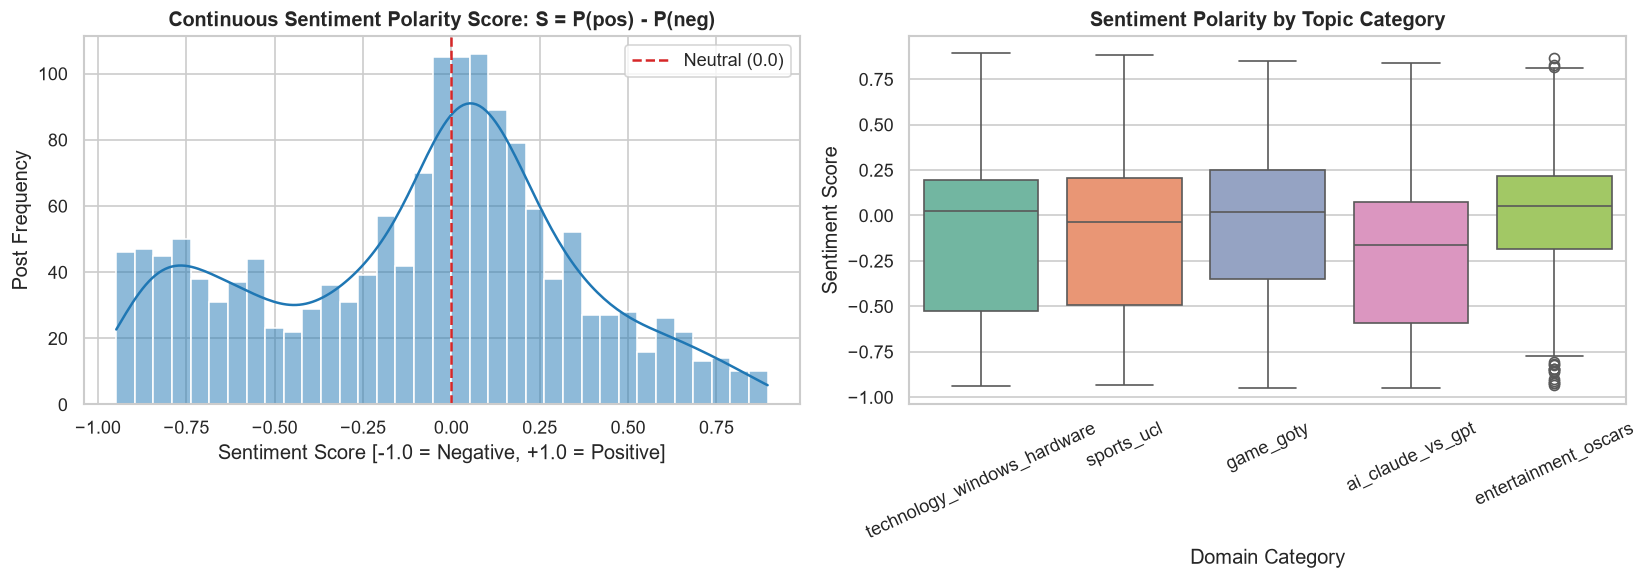

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Histogram & KDE of Sentiment Polarity
sns.histplot(df_sentiment["sentiment_score"], kde=True, bins=35, color="#1f77b4", ax=axes[0])
axes[0].set_title("Continuous Sentiment Polarity Score: S = P(pos) - P(neg)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sentiment Score [-1.0 = Negative, +1.0 = Positive]")
axes[0].set_ylabel("Post Frequency")
axes[0].axvline(0.0, color="#d62728", linestyle="--", lw=1.5, label="Neutral (0.0)")
axes[0].legend()

# Panel 2: Sentiment by Domain Category
sns.boxplot(data=df_sentiment, x="topic_category", y="sentiment_score", palette="Set2", ax=axes[1])
axes[1].set_title("Sentiment Polarity by Topic Category", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Domain Category")
axes[1].set_ylabel("Sentiment Score")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### 5. Stage 4: Topic Discovery with BERTopic (UMAP + HDBSCAN + c-TF-IDF)
Applies non-linear dimensionality reduction (UMAP), density clustering (HDBSCAN), and keyword extraction (c-TF-IDF) to discover semantic clusters.

In [5]:
topics_path = "data/04_topics/posts_with_topics.parquet"
topic_info_path = "data/04_topics/topic_info.csv"

topic_detector = TopicDetector(config.get("stage_04_topic_detection", {}))

if os.path.exists(topics_path) and os.path.exists(topic_info_path):
    print("Loading existing BERTopic results from disk...")
    df_topics = load_dataframe(topics_path)
    topic_info = pd.read_csv(topic_info_path)
else:
    print("Fitting BERTopic on contextual sentence embeddings...")
    df_topics, topic_info = topic_detector.fit_transform(df_sentiment, embeddings)

print(f"Discovered {len(topic_info)} topic clusters (including outlier cluster -1).")
topic_info.head(10)

Loading existing BERTopic results from disk...
Discovered 39 topic clusters (including outlier cluster -1).


,Topic,Count,Name,Representation,Representative_Docs
0,0,104,0_the_league_city_in,"['the', 'league', 'city', 'in', 'to', 'club', ...","[""what would be a realistic punishment for man..."
1,1,106,1_comments_link_submitted_by,"['comments', 'link', 'submitted', 'by', 'this'...","['credited 62,500 credits?. chat gpt credited ..."
2,2,81,2_the_oscars_of_her,"['the', 'oscars', 'of', 'her', 'film', 'his', ...","[""my personal picks for best score 1990-199. (..."
3,3,62,3_amd_ryzen_pro_max,"['amd', 'ryzen', 'pro', 'max', '495', '192gb',...",['amd ryzen 5 5500f is on average 7% faster th...
4,4,67,4_of_the_movies_are,"['of', 'the', 'movies', 'are', 'to', 'is', 'ga...","[""assuming gta vi isn't nominated, what do you..."
5,5,57,5_ryzen_rtx_cpu_my,"['ryzen', 'rtx', 'cpu', 'my', 'gaming', '16gb'...","[""gaming pc building. hi guys, this is my firs..."
6,6,70,6_link_comments_submitted_by,"['link', 'comments', 'submitted', 'by', 'movie...",['help with midra the frenzied in elden ring!!...
7,7,47,7_meta_england_glasses_vr,"['meta', 'england', 'glasses', 'vr', 'talking'...",['the board with adam wingard | a24. subscribe...
8,8,53,8_my_it_and_when,"['my', 'it', 'and', 'when', 'to', 'screen', 'o...","[""how to properly use computer use. i am havin..."
9,9,70,9_astra_ai_the_code,"['astra', 'ai', 'the', 'code', 'with', 'to', '...","[""your dev workflow. do you have a workflow fo..."


### 6. Visualize Top Discovered Topic Clusters by Post Volume

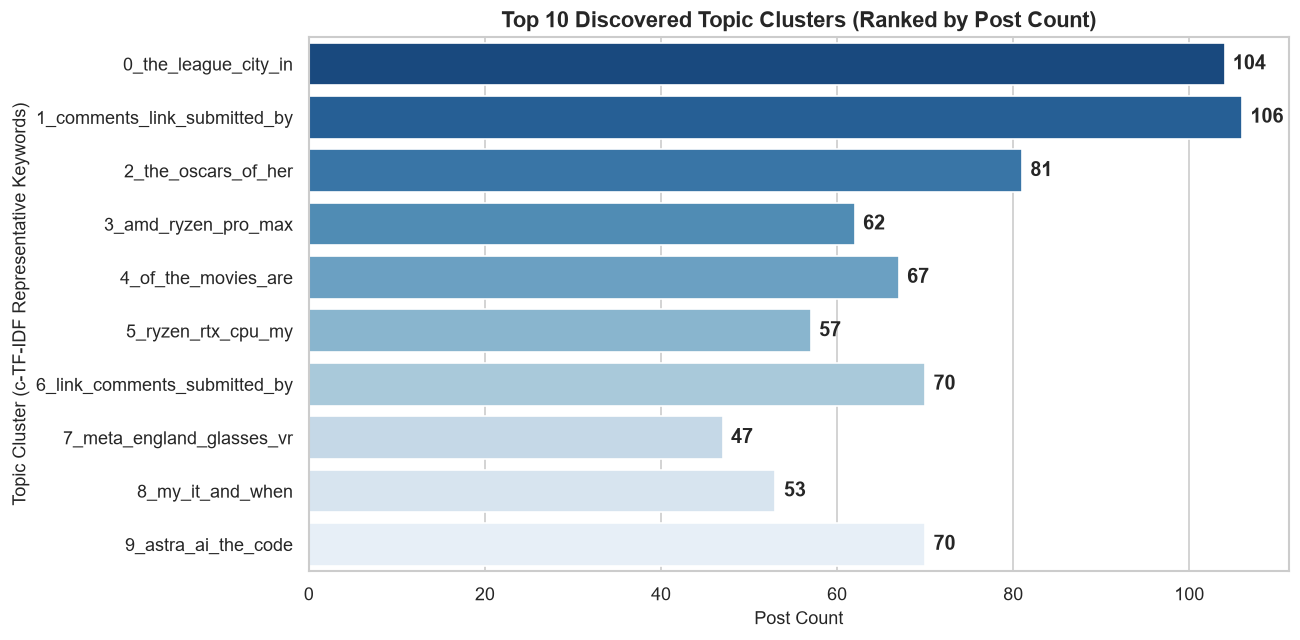

In [6]:
# Filter out noise / outlier cluster (-1) for meaningful topic ranking
coherent_topics = topic_info[topic_info["Topic"] != -1].head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=coherent_topics, y="Name", x="Count", palette="Blues_r", ax=ax, hue="Name", legend=False)
ax.set_title("Top 10 Discovered Topic Clusters (Ranked by Post Count)", fontsize=13, fontweight="bold")
ax.set_xlabel("Post Count", fontsize=11)
ax.set_ylabel("Topic Cluster (c-TF-IDF Representative Keywords)", fontsize=11)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{int(width)}", xy=(width, p.get_y() + p.get_height() / 2), xytext=(5, 0), textcoords="offset points", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 7. Inspect Sample Posts from Discovered Topics
Inspect actual social discussions categorized under discovered topics to verify clustering quality.

In [7]:
# Inspect posts for the top topic
if not coherent_topics.empty:
    sample_topic_id = int(coherent_topics.iloc[0]["Topic"])
    sample_topic_name = coherent_topics.iloc[0]["Name"]
    print(f"=== SAMPLE POSTS FOR TOPIC {sample_topic_id}: {sample_topic_name} ===\n")
    sample_posts = df_topics[df_topics["topic_id"] == sample_topic_id]["cleaned_text"].head(4)
    for idx, post in enumerate(sample_posts, 1):
        print(f"{idx}. {post[:150]}...\n")

=== SAMPLE POSTS FOR TOPIC 0: 0_the_league_city_in ===

1. city should be done like juventus was done. strip their titles and relegate them for cheating.. no matter what way you cheat, by financial means or by...

2. who was better, alexis sanchez or griezmann?. between both, who would you say is the better player? edit: i know many will think this is one side but ...

3. harry kane in his entire career has never once won motm in a big game against a big team. what i mean by a "big game against a big team" is a match ag...

4. manchester city have been found guilty — so where does the line get drawn?. the commission found that the arrangements involved more than £900m in art...

